# Principal Component Analysis with Cancer Data

In [233]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [245]:
can_df = pd.read_csv("cancer.csv")
can_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [90]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [246]:
can_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [247]:
can_df.shape 

(699, 11)

In [248]:
can_df.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [249]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [250]:
can_df.isin([np.nan]).sum(axis=0)

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [251]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [252]:
can_df.isin(['?']).sum(axis=0)

ID                              0
ClumpThickness                  0
Cell Size                       0
Cell Shape                      0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Normal Nucleoli                 0
Bland Chromatin                 0
Mitoses                         0
Class                           0
dtype: int64

In [253]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [254]:
## Removing '?' values and replacing with median
# can_df = can_df.replace('?',np.nan)
# can_df = can_df.apply(lambda x: x.fillna(x.median()),axis=0)

can_df['Bare Nuclei'] = can_df['Bare Nuclei'].replace('?',np.nan)
can_df['Bare Nuclei'] = can_df['Bare Nuclei'].fillna(can_df['Bare Nuclei'].median())

can_df['Bare Nuclei'] = can_df['Bare Nuclei'].astype('int64')  
can_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null int64
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(11)
memory usage: 60.1 KB


In [258]:
## Removing Duplicates
can_df = can_df.drop_duplicates()
can_df.shape

(690, 11)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [243]:
# Check for correlation of variable

In [259]:
can_df.corr()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ID,1.000000,-0.059592,-0.043856,-0.042803,-0.066771,-0.048102,-0.091832,-0.059802,-0.054517,-0.036286,-0.080084
ClumpThickness,-0.059592,1.000000,0.643173,0.653589,0.487715,0.517253,0.590648,0.561063,0.535507,0.350196,0.716812
Cell Size,-0.043856,0.643173,1.000000,0.905349,0.712933,0.746982,0.684571,0.759632,0.727073,0.459918,0.817586
Cell Shape,-0.042803,0.653589,0.905349,1.000000,0.690782,0.714243,0.704165,0.738576,0.724519,0.440435,0.817551
Marginal Adhesion,-0.066771,0.487715,0.712933,0.690782,1.000000,0.608281,0.672512,0.669860,0.602228,0.417008,0.701175
Single Epithelial Cell Size,-0.048102,0.517253,0.746982,0.714243,0.608281,1.000000,0.580487,0.620526,0.633880,0.482517,0.681063
Bare Nuclei,-0.091832,0.590648,0.684571,0.704165,0.672512,0.580487,1.000000,0.672754,0.578161,0.342823,0.816655
Normal Nucleoli,-0.059802,0.561063,0.759632,0.738576,0.669860,0.620526,0.672754,1.000000,0.669099,0.343769,0.756736
Bland Chromatin,-0.054517,0.535507,0.727073,0.724519,0.602228,0.633880,0.578161,0.669099,1.000000,0.427490,0.715363
Mitoses,-0.036286,0.350196,0.459918,0.440435,0.417008,0.482517,0.342823,0.343769,0.427490,1.000000,0.423947


In [ ]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [ ]:
#Let us check for pair plots

C:\Users\pawansinghp\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


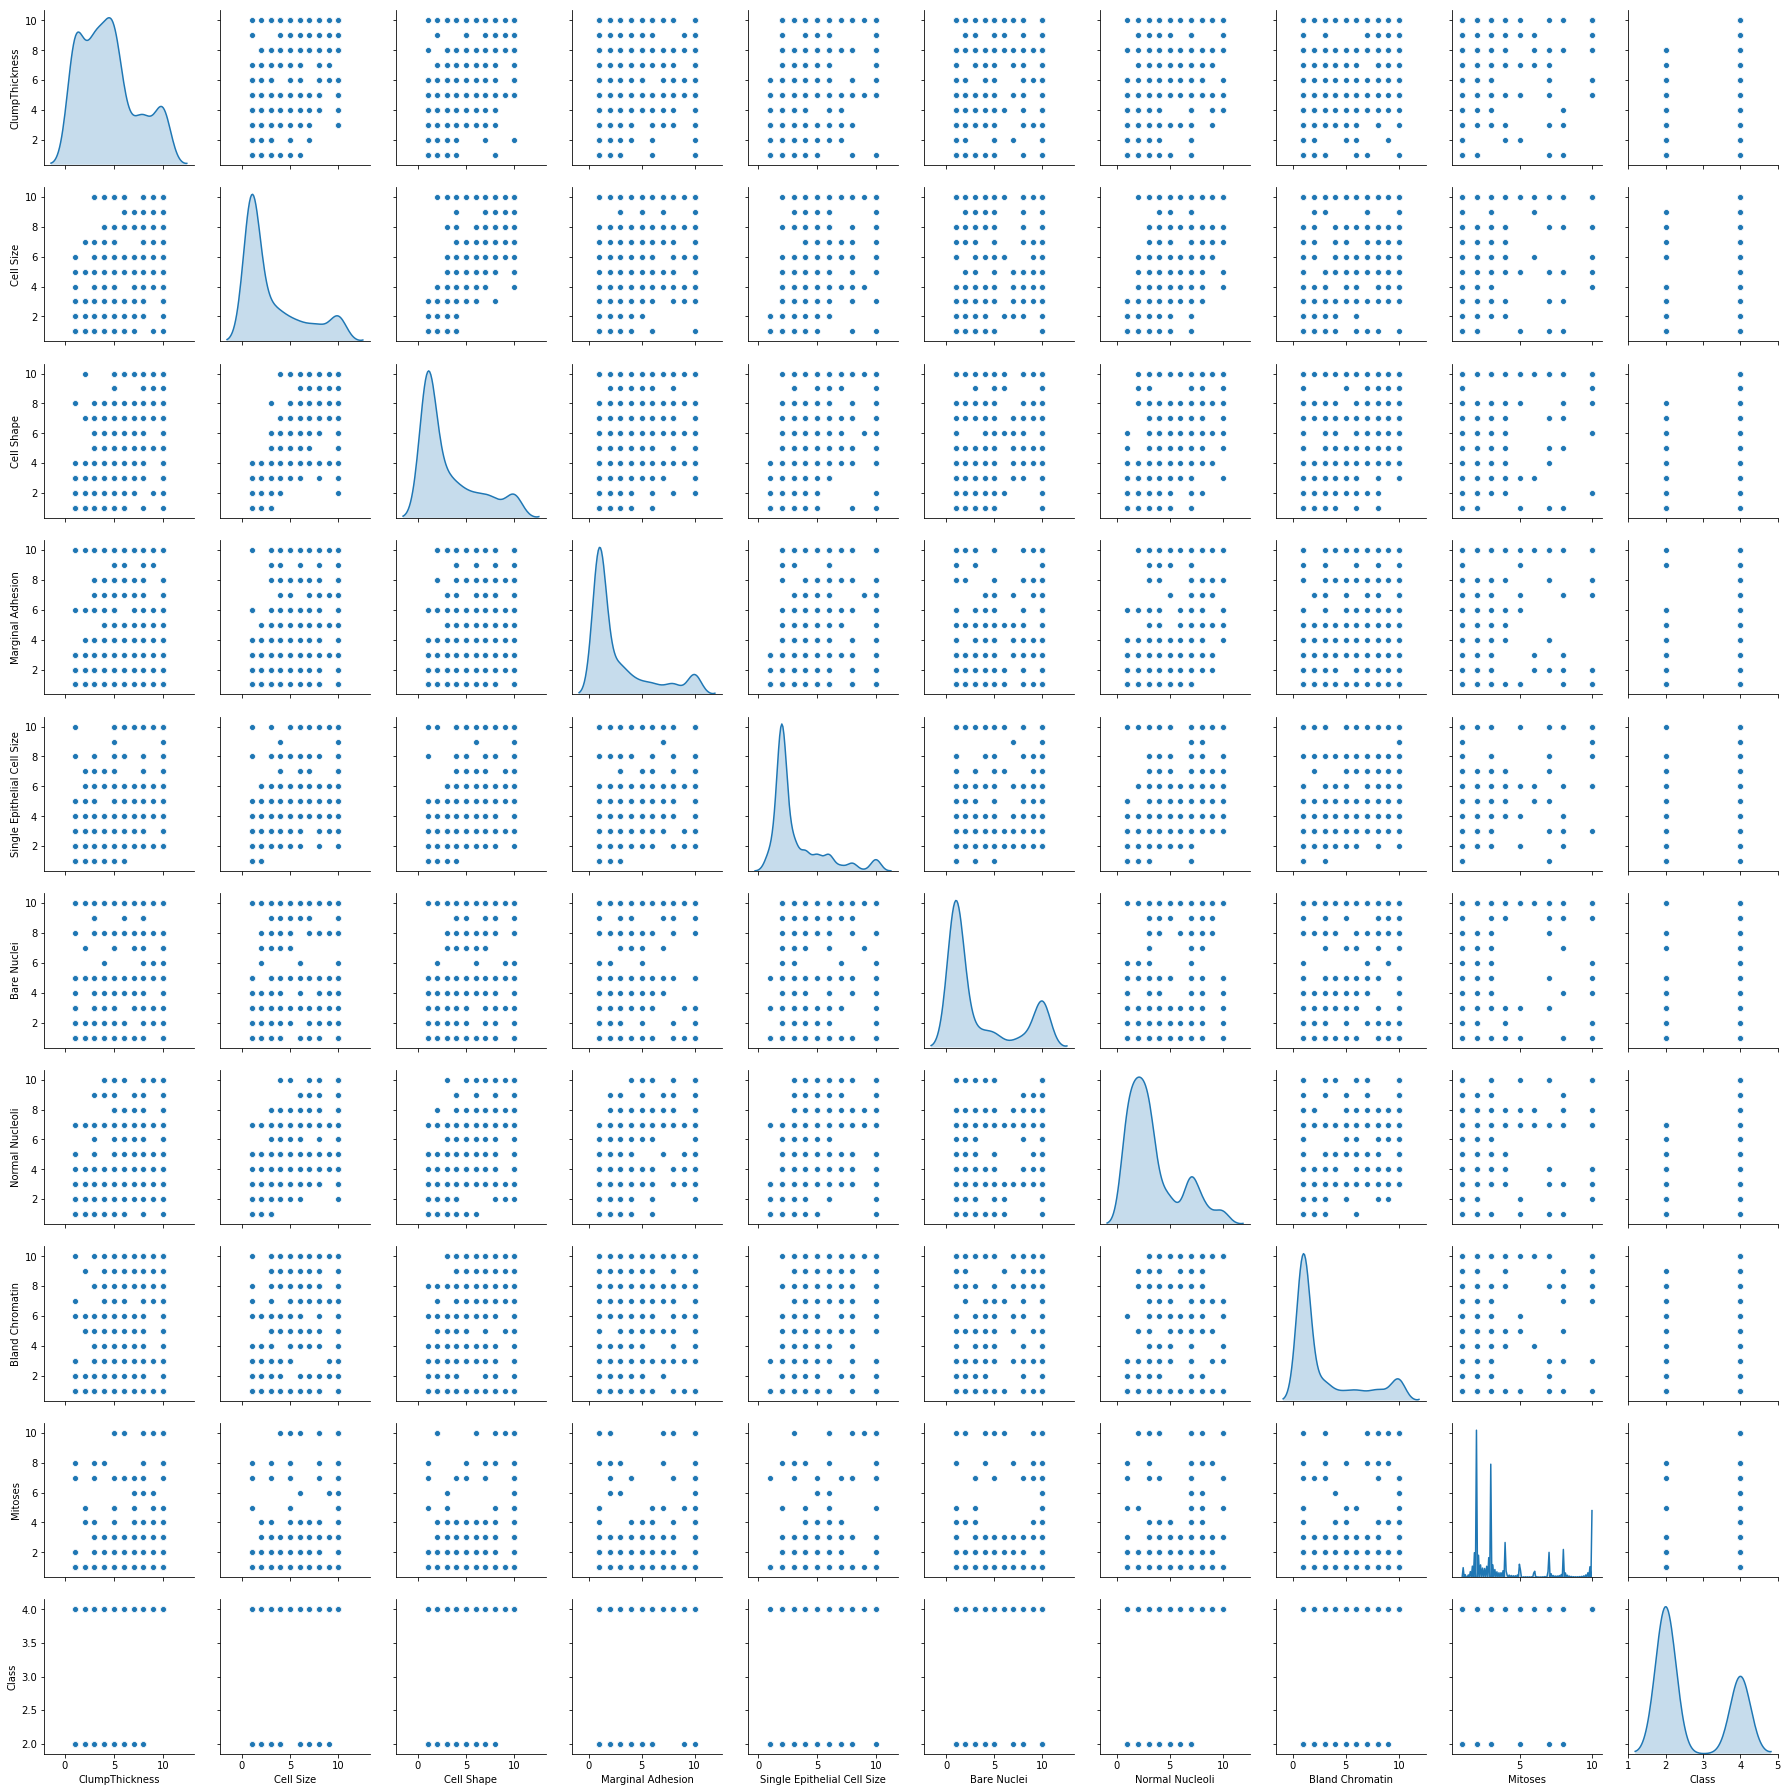

In [292]:
sns.pairplot(can_df,diag_kind='kde')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [ ]:
# We could see most of the outliers are now removed.

In [ ]:
# Less then 1 % outliers in the dataset so ignoring 

In [260]:
can_df.shape

(690, 11)

In [261]:
can_df_ID = can_df['ID']
can_df = can_df.drop('ID', axis=1)
can_df.shape

(690, 10)

In [262]:
y = can_df['Class']
X = can_df.drop('Class', axis=1)

In [263]:
sc = StandardScaler()
X_std =  sc.fit_transform(X)          

C:\Users\pawansinghp\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\pawansinghp\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q6 Create a covariance matrix for identifying Principal components

In [ ]:
# PCA
# Step 1 - Create covariance matrix


In [264]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00145138 0.64410677 0.65453792 0.48842317 0.51800374 0.59150555
  0.56187702 0.53628373 0.35070402]
 [0.64410677 1.00145138 0.9066632  0.71396807 0.74806589 0.68556472
  0.76073447 0.7281282  0.46058509]
 [0.65453792 0.9066632  1.00145138 0.6917849  0.71527957 0.70518656
  0.73964761 0.72557104 0.44107467]
 [0.48842317 0.71396807 0.6917849  1.00145138 0.60916409 0.67348849
  0.67083263 0.60310209 0.41761286]
 [0.51800374 0.74806589 0.71527957 0.60916409 1.00145138 0.58132945
  0.62142658 0.63480034 0.48321685]
 [0.59150555 0.68556472 0.70518656 0.67348849 0.58132945 1.00145138
  0.67373075 0.57900023 0.34332099]
 [0.56187702 0.76073447 0.73964761 0.67083263 0.62142658 0.67373075
  1.00145138 0.67006996 0.34426827]
 [0.53628373 0.7281282  0.72557104 0.60310209 0.63480034 0.57900023
  0.67006996 1.00145138 0.42811085]
 [0.35070402 0.46058509 0.44107467 0.41761286 0.48321685 0.34332099
  0.34426827 0.42811085 1.00145138]]


# Q7 Identify eigen values and eigen vector

In [ ]:
# Step 2- Get eigen values and eigen vector

In [265]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30202869  0.14902209 -0.86872874 -0.00254656 -0.02905197  0.26616691
  -0.19399832 -0.1501391  -0.00300703]
 [-0.38089144  0.04833557  0.03657788 -0.73669737  0.18962075 -0.43946502
  -0.23349186  0.09850317  0.12335951]
 [-0.37721125  0.08333455 -0.02039666  0.66430356  0.16770378 -0.58940349
  -0.15127833  0.06480163  0.08028927]
 [-0.33430954  0.05023423  0.39037637  0.04590901 -0.48684422  0.19404134
  -0.4924605  -0.46232255 -0.0168367 ]
 [-0.33589151 -0.17389022  0.15761632  0.06657451  0.32855055  0.38975065
   0.21090367 -0.06957883  0.72006348]
 [-0.33284901  0.24716817 -0.0294455  -0.07105867 -0.55680581 -0.15915546
   0.69544634  0.01237327  0.05514693]
 [-0.34648894  0.22989544  0.18320773  0.06252437  0.00966191  0.39882942
  -0.12659342  0.73810848 -0.26387659]
 [-0.3364694  -0.02071698  0.1357351  -0.02018486  0.47674458  0.1133626
   0.31256571 -0.41188028 -0.60004044]
 [-0.22972022 -0.90629849 -0.11603305  0.0080874  -0.22956737 -0.04272175
   0.

# Q8 Find variance and cumulative variance by each eigen vector

In [276]:
total = sum(eigenvalues)
var_explained = [(i / tot) * 100 for i in sorted(eigenvalues, reverse=True)] 

In [277]:
print("Variance Explained",var_explained)

Variance Explained [65.5555449176843, 8.621470583728472, 6.000632301898074, 5.174778114391022, 4.11443094621517, 3.3494485001343675, 3.2566105503004166, 2.9235017128573246, 1.0037924131397644]


In [278]:
cum_var_exp = np.cumsum(var_explained)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 65.55554492  74.1770155   80.1776478   85.35242592  89.46685686
  92.81630536  96.07291591  98.99641763 100.00021004]


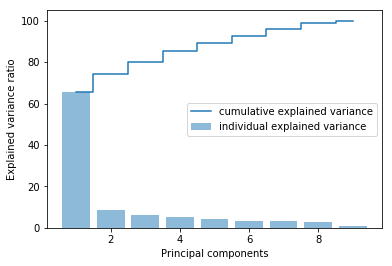

In [279]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [299]:
from sklearn.decomposition import PCA
pca = PCA(n_components=6)

In [300]:
pca.fit(X)

PCA(copy=True, iterated_power='auto', n_components=6, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [301]:
pca.components_

array([[ 0.29790598,  0.40288343,  0.39036924,  0.33486161,  0.24788681,
         0.43846304,  0.29337155,  0.35940496,  0.12441877],
       [-0.07834808,  0.22830231,  0.16909421, -0.10691758,  0.18578596,
        -0.78277369,  0.02271213,  0.47756049,  0.16088652],
       [-0.85683651, -0.01508952, -0.06620179,  0.47574671,  0.06563439,
         0.09229095,  0.09795858,  0.10737837,  0.03056792],
       [ 0.11349478,  0.26033305,  0.17336622,  0.43812425,  0.17216447,
        -0.32754148, -0.03922063, -0.72815635,  0.16930143],
       [ 0.35757784, -0.380397  , -0.41011346,  0.56125503, -0.10210995,
        -0.10435281, -0.17300301,  0.27209769,  0.34489536],
       [-0.14500322, -0.01086168, -0.00551808, -0.31263819,  0.43183818,
         0.24978568, -0.43434565, -0.04832997,  0.66423939]])

In [302]:
pcadf = pd.DataFrame(pca.components_)
pcadf

,0,1,2,3,4,5,6,7,8
0,0.297906,0.402883,0.390369,0.334862,0.247887,0.438463,0.293372,0.359405,0.124419
1,-0.078348,0.228302,0.169094,-0.106918,0.185786,-0.782774,0.022712,0.477560,0.160887
2,-0.856837,-0.015090,-0.066202,0.475747,0.065634,0.092291,0.097959,0.107378,0.030568
3,0.113495,0.260333,0.173366,0.438124,0.172164,-0.327541,-0.039221,-0.728156,0.169301
4,0.357578,-0.380397,-0.410113,0.561255,-0.102110,-0.104353,-0.173003,0.272098,0.344895
5,-0.145003,-0.010862,-0.005518,-0.312638,0.431838,0.249786,-0.434346,-0.048330,0.664239


In [303]:
Xpca = pca.transform(X)

In [304]:
Xpca.shape

(690, 6)

# Q10 Find correlation between components and features

In [ ]:
## Unsure as to whether we have to find the correlation between the transformed dataset by PCA (Xpca) 
## OR on the components of PCA itself
## So doing both.

In [ ]:
## Correlation between transformed features of data by PCA

C:\Users\pawansinghp\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


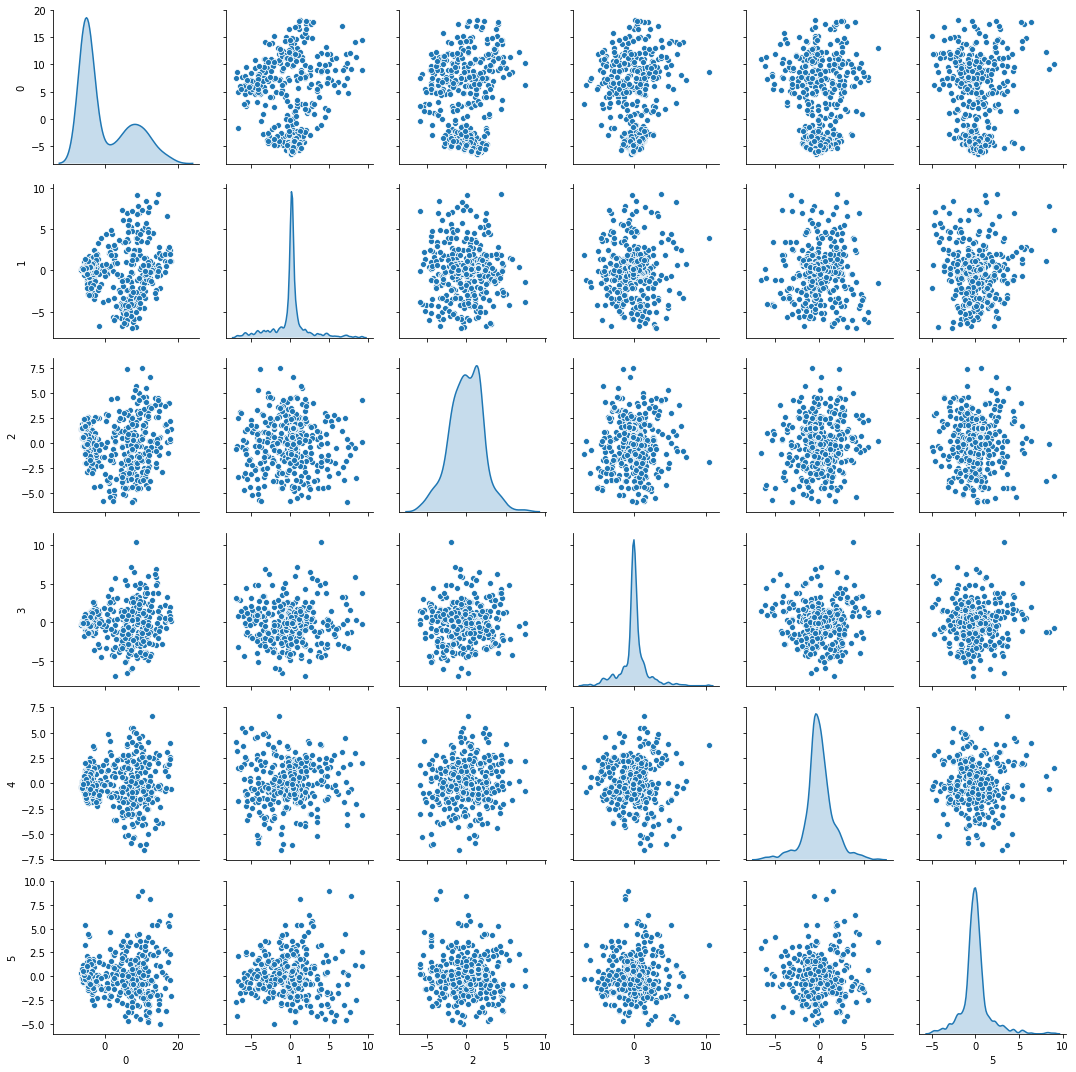

In [308]:
pcadf = pd.DataFrame(Xpca)
sns.pairplot(pcadf,diag_kind='kde')

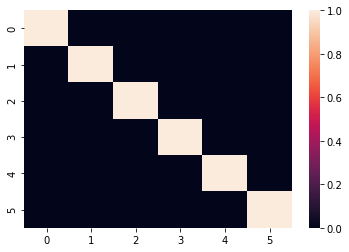

In [309]:
sns.heatmap(pcadf.corr())

In [ ]:
## Correlation between dimensions of Principal Components

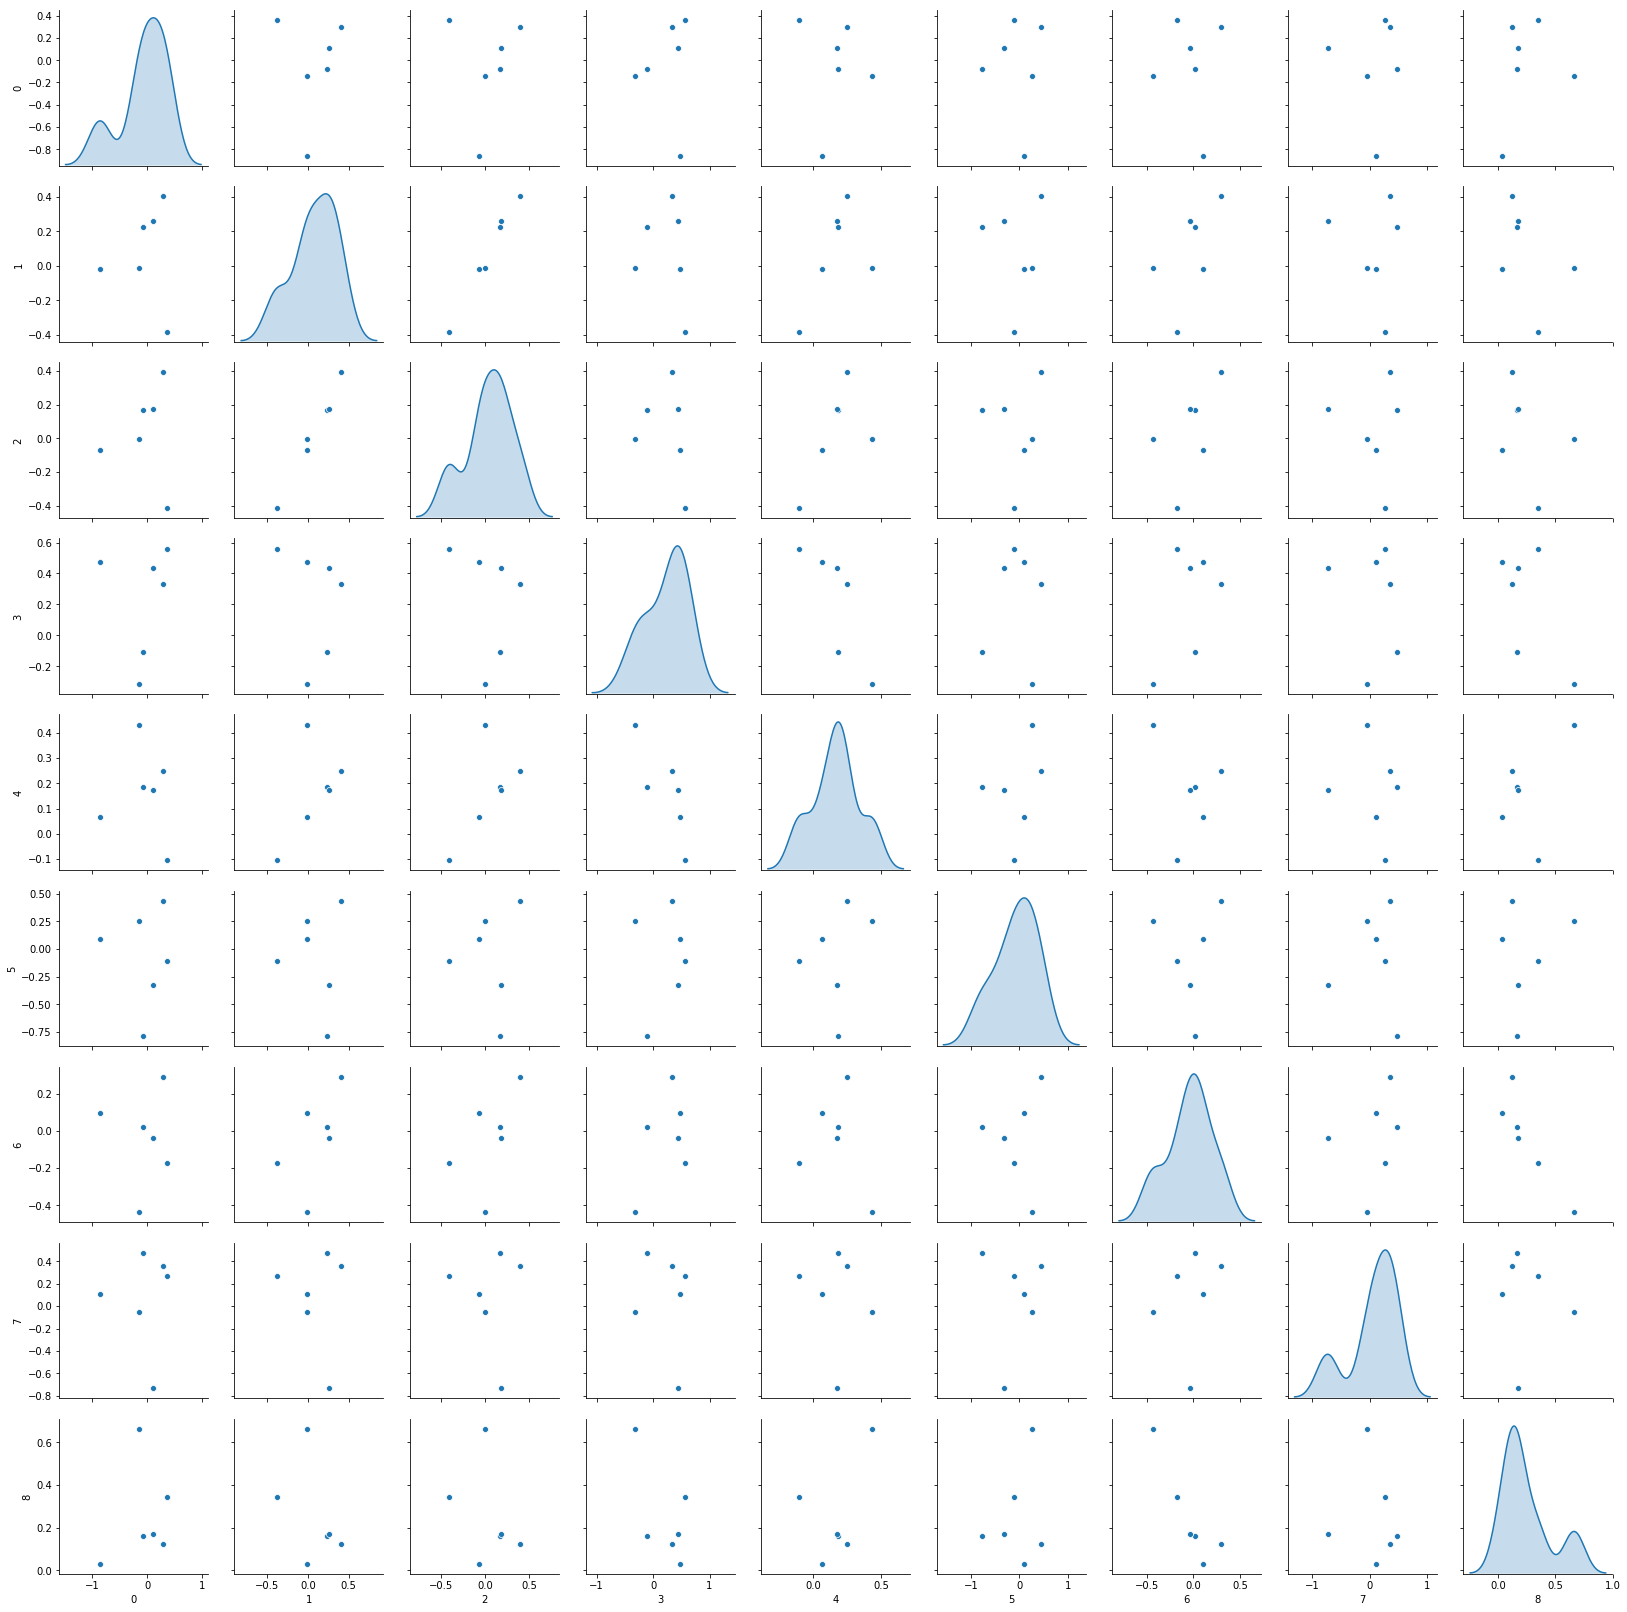

In [310]:
pcadfComp = pd.DataFrame(pca.components_)
sns.pairplot(pcadfComp,diag_kind='kde')

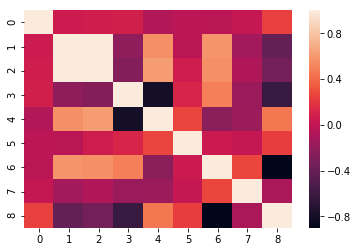

In [312]:
sns.heatmap(pcadfComp.corr())